In [1]:
# 리소스 준비

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 시각화 동작 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 학습 리소스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

사용 디바이스: cpu


In [2]:
# 데이터셋, 데이터로더 준비

# 사전학습 모델은 ImageNet 크기(224×224) 기준
# CIFAR-10(32×32)을 224×224로 리사이즈 필요
transfer_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet 평균
                         std=[0.229, 0.224, 0.225])    # ImageNet 표준편차
])

train_ds_tl = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=False, transform=transfer_transform)
test_ds_tl  = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=False, transform=transfer_transform)

train_loader_tl = DataLoader(train_ds_tl, batch_size=32, shuffle=True,  num_workers=2)
test_loader_tl  = DataLoader(test_ds_tl,  batch_size=32, shuffle=False, num_workers=2)

CLASSES = ["비행기","자동차","새","고양이","사슴",
           "개","개구리","말","배","트럭"]

print(f"훈련 샘플: {len(train_ds_tl):,} | 테스트 샘플: {len(test_ds_tl):,}")
print(f"훈련 배치 수: {len(train_loader_tl)}")


훈련 샘플: 50,000 | 테스트 샘플: 10,000
훈련 배치 수: 1563


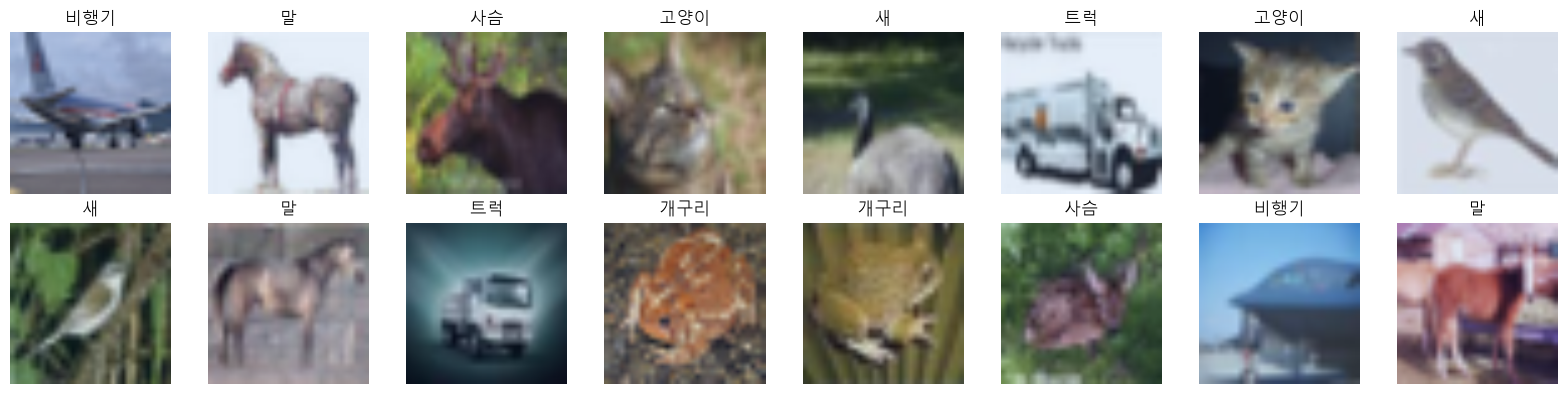

In [3]:
# 샘플 이미지 시각화
images, labels = next(iter(train_loader_tl))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    img = images[i].permute(1, 2, 0)   # (C,H,W) → (H,W,C)
    img = img * 0.2 + 0.45             # 정규화 역변환 (근사)
    ax.imshow(img.clamp(0, 1))
    ax.set_title(CLASSES[labels[i]])
    ax.axis("off")
plt.tight_layout()
plt.show()


In [4]:
import torchvision.models as models

# ResNet-50 사전학습 모델 로딩
backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# 모든 레이어 동결 (학습 동결)
for param in backbone.parameters():
    param.requires_grad = False

# 마지막 분류층만 교체 (CIFAR-10: 10 클래스)
in_features = backbone.fc.in_features     # 2048
backbone.fc = nn.Linear(in_features, 10)  # 새 분류층은 자동으로 학습 가능

model_fe = backbone.to(device)

# 학습 가능한 파라미터만 확인
trainable = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_fe.parameters())
print(f"학습 파라미터: {trainable:,} / 전체: {total:,} ({trainable/total:.1%})")

6.3%

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\human/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100.0%


학습 파라미터: 20,490 / 전체: 23,528,522 (0.1%)


In [ ]:
# 훈련 및 평가 함수

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (pred.argmax(1) == y).sum().item()
        total      += y.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred  = model(X)
            total_loss += criterion(pred, y).item()
            correct    += (pred.argmax(1) == y).sum().item()
            total      += y.size(0)

    return total_loss / len(loader), correct / total


In [6]:
# 학습(훈련) 설계

# 훈련 (동일한 train_epoch / eval_epoch 함수 재사용)
EPOCHS_TL = 10
criterion_tl = nn.CrossEntropyLoss()
optimizer_fe = torch.optim.Adam(backbone.fc.parameters(), lr=0.001)
scheduler_tl = torch.optim.lr_scheduler.StepLR(optimizer_fe, step_size=5, gamma=0.1)


In [8]:
# 학습(훈련) 실행
best_tl_acc = 0.0
for epoch in range(1, EPOCHS_TL + 1):
    tr_loss, tr_acc = train_epoch(model_fe, train_loader_tl, criterion_tl, optimizer_fe, device)
    va_loss, va_acc = eval_epoch(model_fe, test_loader_tl,  criterion_tl, device)
    scheduler_tl.step()

    if va_acc > best_tl_acc:
        best_tl_acc = va_acc
        torch.save(model_fe.state_dict(), "efficientnet_best.pt")

    print(f"Epoch {epoch:>2} | Train {tr_acc:.2%} | Val {va_acc:.2%}")

print(f"\n최고 정확도 (EfficientNet Fine-Tuning): {best_tl_acc:.2%}")


NameError: name 'train_epoch' is not defined

In [ ]:
# 학습 곡선
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="validation")
axes[0].set_title("loss curve")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"],   label="validation")
axes[1].set_title("accuracy curve")
axes[1].set_xlabel("epoch")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cnn_training_curve.png", dpi=100, bbox_inches="tight")
plt.show()